In [1]:
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import joblib

# Load the trained model from the file
model_filename='../../inflammation_HANNUM_with_proper_selection/inflammation_model_1.pkl'
loaded_pipeline = joblib.load(model_filename)

import pandas as pd
hannum_raw_table = pd.read_csv('../../inflammation_HANNUM_with_proper_selection/raw_table_inflammation_genes_only.csv', delimiter='\t', index_col=0)

In [10]:
rejuv_raw = pd.read_csv('../gse54848_raw.csv', delimiter=',', index_col=0)

In [11]:
# LUCKILY ALL OF THE HANNUM ROWS ARE IN THIS DATASET
rejuv_raw_filtered = rejuv_raw[rejuv_raw.index.isin(hannum_features_in_order)] #CHECK, THE DATAFRAMES SHAPE IS 1293 * ...
#NOW REORDER SO IT WILL BE IN THE SAME ORDER AS THE INFLAMMATION ONLY HANNUM DATA
rejuv_raw_reordered = rejuv_raw_filtered.reindex(hannum_features_in_order)

In [14]:
import numpy as np

# Initialize an empty dictionary to store predictions with column names
predictions_with_colnames = {}

# Iterate through all columns of the DataFrame
for col in rejuv_raw_reordered.columns:
    # Extract the column as a 1D array and reshape it into a 2D array
    X_test = np.array(rejuv_raw_reordered[col]).reshape(1, -1)
    
    # Predict using the loaded pipeline
    prediction = loaded_pipeline.predict(X_test)
    
    # Store the prediction with the column name
    predictions_with_colnames[col] = prediction

# Print the predictions with their respective column names
for col_name, prediction in predictions_with_colnames.items():
    print(f"Column: {col_name}, Prediction: {prediction}")

Column: Day0_1, Prediction: [56.7545499]
Column: Day0_2, Prediction: [51.43499981]
Column: Day0_3, Prediction: [54.98659952]
Column: Day3_1, Prediction: [54.35652582]
Column: Day3_2, Prediction: [45.44389753]
Column: Day7_1, Prediction: [51.57932094]
Column: Day7_2, Prediction: [48.69316563]
Column: Day7_3, Prediction: [59.12196739]
Column: Day11_1, Prediction: [36.29342101]
Column: Day11_2, Prediction: [19.51006586]
Column: Day11_3, Prediction: [49.44859352]
Column: Day15_1, Prediction: [-5.23461198]
Column: Day15_2, Prediction: [35.86740587]
Column: Day20_1, Prediction: [-4.11455189]
Column: Day20_2, Prediction: [-0.84522944]
Column: Day28_1, Prediction: [2.70469446]
Column: Day28_2, Prediction: [0.19400249]
Column: Day28_3, Prediction: [-10.39877099]
Column: p1_1, Prediction: [-16.86278544]
Column: p1_2, Prediction: [-14.9949551]
Column: p1_3, Prediction: [-18.16986849]
Column: p2_1, Prediction: [-19.22579476]
Column: p2_2, Prediction: [-18.05295934]
Column: p2_3, Prediction: [-18.7

Column Names: ['Day0_1', 'Day0_2', 'Day0_3', 'Day3_1', 'Day3_2', 'Day7_1', 'Day7_2', 'Day7_3', 'Day11_1', 'Day11_2', 'Day11_3', 'Day15_1', 'Day15_2', 'Day20_1', 'Day20_2', 'Day28_1', 'Day28_2', 'Day28_3', 'p1_1', 'p1_2', 'p1_3', 'p2_1', 'p2_2', 'p2_3', 'p3_1', 'p3_2', 'p3_3', 'H9_1', 'H9_2', '201B7']
Predictions: [56.75454989709311, 51.43499981245472, 54.98659951857981, 54.356525815341115, 45.443897530395226, 51.579320943043136, 48.69316563318815, 59.12196738790304, 36.29342101100174, 19.510065856060407, 49.448593518985774, -5.234611982811117, 35.86740586739678, -4.114551887684016, -0.845229444273329, 2.704694456398208, 0.19400248703620804, -10.398770989497834, -16.862785440768533, -14.994955099764255, -18.169868488426346, -19.225794755817446, -18.052959335429577, -18.73017125062775, -11.323793752263597, -10.544484105215247, -15.124118038814117, -10.903516024816014, -9.76149099961647, -17.855603563186506]


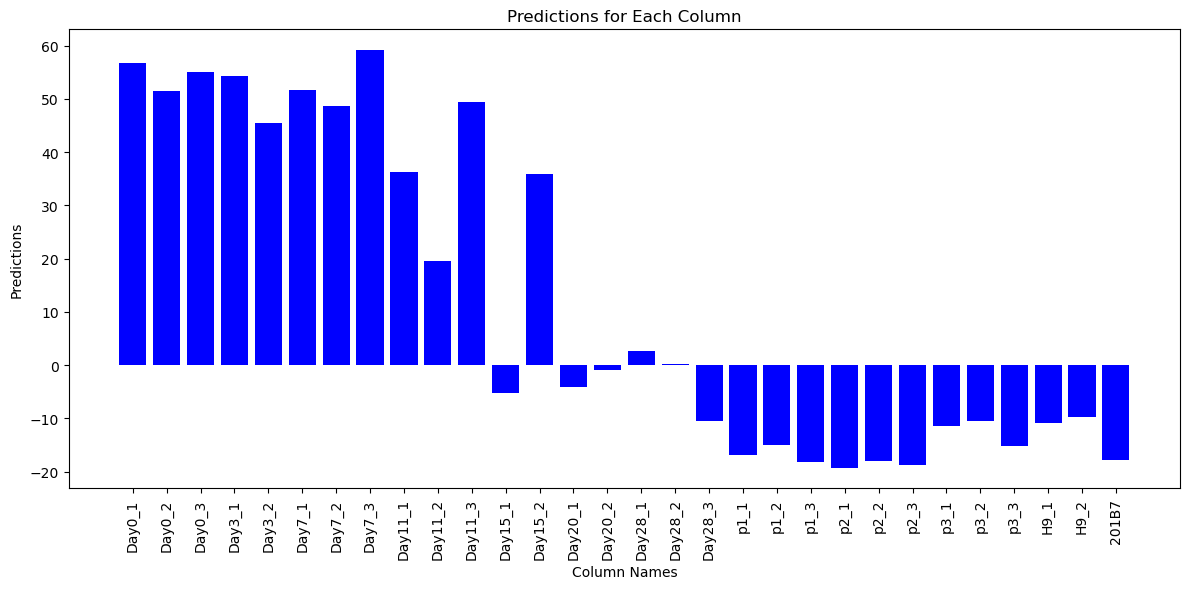

In [15]:
import matplotlib.pyplot as plt

# Extract column names and predictions
col_names = list(predictions_with_colnames.keys())  # List of strings (column names)
predictions = [prediction[0] for prediction in predictions_with_colnames.values()]  # Extract the value from each array

# Ensure the data is correctly formatted
print("Column Names:", col_names)
print("Predictions:", predictions)

# Plot the predictions
plt.figure(figsize=(12, 6))  # Adjust the size of the plot if necessary
plt.bar(col_names, predictions, color='blue')

# Add labels and title
plt.xlabel('Column Names')
plt.ylabel('Predictions')
plt.title('Predictions for Each Column')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()  # To make sure the labels fit well
plt.show()


In [39]:
import matplotlib.pyplot as plt

# Extract column names and predictions
col_names = [0,3,7,11,15,20,28,35,42,49]  # List of strings (column names)
predictions = [prediction[0] for prediction in predictions_with_colnames.values()]  # Extract the value from each array
summarised_predictions=list()
summarised_predictions.append([predictions[0],predictions[1],predictions[2]])#day0
summarised_predictions.append([predictions[3],predictions[4]])#day3
summarised_predictions.append([predictions[5],predictions[6],predictions[7]])#day7
summarised_predictions.append([predictions[8],predictions[9],predictions[10]])#day11
summarised_predictions.append([predictions[11],predictions[12]])#day15
summarised_predictions.append([predictions[13],predictions[14]])#day20
summarised_predictions.append([predictions[15],predictions[16],predictions[17]])#day28
summarised_predictions.append([predictions[18],predictions[19],predictions[20]])#day35
summarised_predictions.append([predictions[21],predictions[22],predictions[23]])#day42
summarised_predictions.append([predictions[24],predictions[25],predictions[26]])#day49


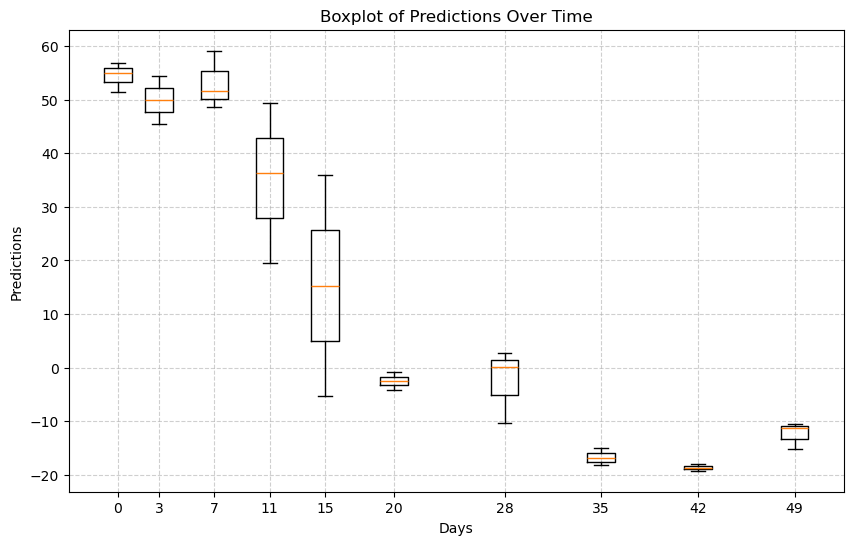

In [35]:
import matplotlib.pyplot as plt

# Define your x-axis labels
col_names = [0, 3, 7, 11, 15, 20, 28, 35, 42, 49]

# summarised_predictions is a list of lists
# Each inner list represents a set of values for a given x-axis position

plt.figure(figsize=(10, 6))  # Set figure size
plt.boxplot(summarised_predictions, positions=col_names, widths=2)  # Create boxplot

# Formatting
plt.xticks(col_names)  # Set x-axis ticks
plt.xlabel("Days")  # Label for x-axis
plt.ylabel("Predictions")  # Label for y-axis
plt.title("Boxplot of Predictions Over Time")  # Title
plt.grid(True, linestyle="--", alpha=0.6)  # Add grid for better readability

plt.show()  # Display plot


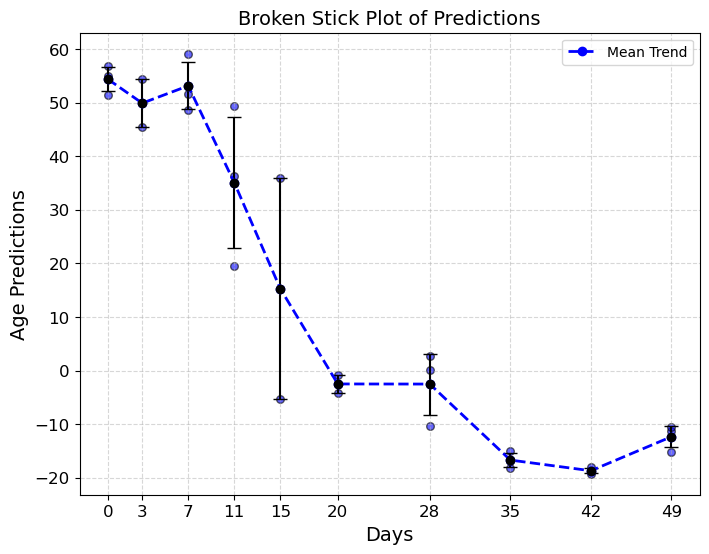

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis labels (days)
col_names = np.array([0, 3, 7, 11, 15, 20, 28, 35, 42, 49])


# Calculate means and standard deviations
means = [np.mean(values) for values in summarised_predictions]
stds = [np.std(values) for values in summarised_predictions]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot individual data points
for x, data in zip(col_names, summarised_predictions):
    plt.scatter([x] * len(data), data, color="blue", edgecolors="black", alpha=0.6, s=30)

# Plot vertical lines (error bars) instead of boxplots
plt.errorbar(col_names, means, yerr=stds, fmt='o', color='black', capsize=5, elinewidth=1.5)

# Connect means with a broken stick (dashed line)
plt.plot(col_names, means, linestyle="--", color="blue", linewidth=2, marker='o', markersize=6, label="Mean Trend")

# Formatting
plt.xticks(col_names, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Days", fontsize=14)
plt.ylabel("Age Predictions", fontsize=14)
plt.title("Broken Stick Plot of Predictions", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()
